In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#ignore warningss
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

## 데이터 불러오기

In [3]:
df_trn = pd.read_csv('train.csv').copy()
df_tst = pd.read_csv('test.csv').copy()
df_sub = pd.read_csv('submission.csv').copy()

In [4]:
df_trn.head()

,ID,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,...,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack
0,346631,Montana,Male,Excellent,0.0,0.0,5 or more years ago,Yes,7.0,1 to 5,...,85.73,21.29,No,No,Yes,No,"Yes, received tetanus shot, but not Tdap",No,Yes,0
1,147983,Kansas,Female,Very good,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,...,77.11,NaN,Yes,No,Yes,No,"Yes, received Tdap",No,No,0
2,63785,Indiana,Male,Good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,1 to 5,...,89.81,31.96,Yes,NaN,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No,0
3,43439,Virginia,Female,Very good,1.0,1.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,...,68.04,24.96,Yes,No,No,Yes,"Yes, received Tdap",No,No,0
4,285789,Ohio,Female,Good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,...,81.65,27.37,Yes,Yes,Yes,No,"Yes, received Tdap",No,No,0


In [5]:
df_tst.head()

,ID,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,425295,Massachusetts,Male,Good,5.0,0.0,Within past 5 years (2 years but less than 5 y...,Yes,7.0,None of them,...,NaN,83.91,NaN,Yes,Yes,Yes,Yes,"Yes, received Tdap",No,No
1,169359,Louisiana,Male,Good,0.0,21.0,Within past year (anytime less than 12 months ...,No,8.0,1 to 5,...,1.75,65.77,21.41,Yes,Yes,No,Yes,"Yes, received Tdap",No,No
2,69449,New Hampshire,Male,Good,4.0,2.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,...,1.88,92.08,26.06,No,No,Yes,NaN,"Yes, received tetanus shot but not sure what type",No,No
3,10517,Ohio,Male,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,1 to 5,...,1.70,72.57,25.06,Yes,No,No,No,"Yes, received tetanus shot, but not Tdap",No,Yes
4,62046,Indiana,Male,Good,0.0,20.0,Within past year (anytime less than 12 months ...,No,5.0,NaN,...,NaN,NaN,NaN,Yes,No,Yes,No,"No, did not receive any tetanus shot in the pa...",No,Yes


In [6]:
df_trn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353653 entries, 0 to 353652
Data columns (total 41 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         353653 non-null  int64  
 1   State                      353653 non-null  object 
 2   Sex                        353653 non-null  object 
 3   GeneralHealth              352798 non-null  object 
 4   PhysicalHealthDays         345169 non-null  float64
 5   MentalHealthDays           346556 non-null  float64
 6   LastCheckupTime            347270 non-null  object 
 7   PhysicalActivities         352859 non-null  object 
 8   SleepHours                 349494 non-null  float64
 9   RemovedTeeth               344795 non-null  object 
 10  HadAngina                  350785 non-null  object 
 11  HadStroke                  352757 non-null  object 
 12  HadAsthma                  352484 non-null  object 
 13  HadSkinCancer              35

In [7]:
df_tst.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88414 entries, 0 to 88413
Data columns (total 40 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         88414 non-null  int64  
 1   State                      88414 non-null  object 
 2   Sex                        88414 non-null  object 
 3   GeneralHealth              88174 non-null  object 
 4   PhysicalHealthDays         86301 non-null  float64
 5   MentalHealthDays           86719 non-null  float64
 6   LastCheckupTime            86756 non-null  object 
 7   PhysicalActivities         88236 non-null  object 
 8   SleepHours                 87377 non-null  float64
 9   RemovedTeeth               86262 non-null  object 
 10  HadAngina                  87694 non-null  object 
 11  HadStroke                  88240 non-null  object 
 12  HadAsthma                  88146 non-null  object 
 13  HadSkinCancer              87842 non-null  obj

In [8]:
for col in df_trn.columns:
    msg = 'column: {:>10}\t Percent of NaN value: {:.2f}%'.format(col, 100 * df_trn[col].isnull().sum() / df_trn[col].shape[0])
    print(msg)

column:         ID	 Percent of NaN value: 0.00%
column:      State	 Percent of NaN value: 0.00%
column:        Sex	 Percent of NaN value: 0.00%
column: GeneralHealth	 Percent of NaN value: 0.24%
column: PhysicalHealthDays	 Percent of NaN value: 2.40%
column: MentalHealthDays	 Percent of NaN value: 2.01%
column: LastCheckupTime	 Percent of NaN value: 1.80%
column: PhysicalActivities	 Percent of NaN value: 0.22%
column: SleepHours	 Percent of NaN value: 1.18%
column: RemovedTeeth	 Percent of NaN value: 2.50%
column:  HadAngina	 Percent of NaN value: 0.81%
column:  HadStroke	 Percent of NaN value: 0.25%
column:  HadAsthma	 Percent of NaN value: 0.33%
column: HadSkinCancer	 Percent of NaN value: 0.62%
column:    HadCOPD	 Percent of NaN value: 0.42%
column: HadDepressiveDisorder	 Percent of NaN value: 0.55%
column: HadKidneyDisease	 Percent of NaN value: 0.36%
column: HadArthritis	 Percent of NaN value: 0.53%
column: HadDiabetes	 Percent of NaN value: 0.18%
column: DeafOrHardOfHearing	 Perc

In [9]:
for col in df_tst.columns:
    msg = 'column: {:>10}\t Percent of NaN value: {:.2f}%'.format(col, 100 * df_tst[col].isnull().sum() / df_tst[col].shape[0])
    print(msg)

column:         ID	 Percent of NaN value: 0.00%
column:      State	 Percent of NaN value: 0.00%
column:        Sex	 Percent of NaN value: 0.00%
column: GeneralHealth	 Percent of NaN value: 0.27%
column: PhysicalHealthDays	 Percent of NaN value: 2.39%
column: MentalHealthDays	 Percent of NaN value: 1.92%
column: LastCheckupTime	 Percent of NaN value: 1.88%
column: PhysicalActivities	 Percent of NaN value: 0.20%
column: SleepHours	 Percent of NaN value: 1.17%
column: RemovedTeeth	 Percent of NaN value: 2.43%
column:  HadAngina	 Percent of NaN value: 0.81%
column:  HadStroke	 Percent of NaN value: 0.20%
column:  HadAsthma	 Percent of NaN value: 0.30%
column: HadSkinCancer	 Percent of NaN value: 0.65%
column:    HadCOPD	 Percent of NaN value: 0.40%
column: HadDepressiveDisorder	 Percent of NaN value: 0.53%
column: HadKidneyDisease	 Percent of NaN value: 0.38%
column: HadArthritis	 Percent of NaN value: 0.49%
column: HadDiabetes	 Percent of NaN value: 0.18%
column: DeafOrHardOfHearing	 Perc

## 'State' 변수 삭제

In [10]:
df_trn.drop('State', axis=1, inplace=True)
df_tst.drop('State', axis=1, inplace=True)

## 수치형, 범주형 변수 정의

In [11]:
total_cols = [x for x in df_trn.columns]

id_cols = ['ID']
y_cols = ['HadHeartAttack']

cat_cols_org = df_trn.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_org = [x for x in df_trn if x not in id_cols+y_cols+cat_cols_org]

## 범주형 변수 매핑 & 인코딩

In [12]:
# 건강 상태를 수치형 값으로 매핑 (GeneralHealth 컬럼 변환)
# 'Excellent'는 가장 좋은 상태로 0, 'Poor'는 가장 나쁜 상태로 1로 설정
# 각 상태 사이의 등간척도(scale)를 고려해 단계적으로 값을 부여함
df_trn['GeneralHealth'] = df_trn['GeneralHealth'].map({'Excellent': 0, 'Very good': 0.2, 'Good': 0.4,
                                                       'Fair': 0.6, 'Poor': 1})
df_tst['GeneralHealth'] = df_tst['GeneralHealth'].map({'Excellent': 0, 'Very good': 0.2, 'Good': 0.4,
                                                       'Fair': 0.6, 'Poor': 1})

In [13]:
# 연령대(AgeCategory)를 수치형 값으로 매핑
# 각 연령대 범위를 대표하는 중앙값으로 변환하여 수치화
age_category_mapping = {
    'Age 18 to 24': 21,
    'Age 25 to 29': 27,
    'Age 30 to 34': 32,
    'Age 35 to 39': 37,
    'Age 40 to 44': 42,
    'Age 45 to 49': 47,
    'Age 50 to 54': 52,
    'Age 55 to 59': 57,
    'Age 60 to 64': 62,
    'Age 65 to 69': 67,
    'Age 70 to 74': 72,
    'Age 75 to 79': 77
}

df_trn['AgeCategory'] = df_trn['AgeCategory'].map(age_category_mapping)
df_tst['AgeCategory'] = df_tst['AgeCategory'].map(age_category_mapping)

In [14]:
# 성별(Sex)을 수치형 값으로 매핑
# 성별 데이터를 인구 통계 비율로 변환하여 정보 손실을 최소화
# 학습 데이터(df_trn)와 테스트 데이터(df_tst)의 성별 비율이 약간 다름을 반영
# 예: 'Male' -> 학습 데이터에서 0.530172, 테스트 데이터에서 0.531839
df_trn['Sex'] = df_trn['Sex'].map({'Male': 0.530172, 'Female': 0.469828}) 
df_tst['Sex'] = df_tst['Sex'].map({'Male': 0.531839, 'Female': 0.468161})

In [15]:
# 'HadDiabetes' 열에서 특정 값들을 간소화하여 데이터 정리
# 'No, pre-diabetes or borderline diabetes' -> 'No'로 대체
#   - 경계성 당뇨를 포함한 경우를 'No'(당뇨 없음)로 간소화
# 'Yes, but only during pregnancy (female)' -> 'Yes'로 대체
#   - 임신 중 당뇨를 포함하여 'Yes'(당뇨 있음)로 간소화
# 학습 데이터(df_trn)와 테스트 데이터(df_tst)에 동일한 대체 작업 수행
df_trn['HadDiabetes'] = df_trn['HadDiabetes'].replace({
    'No, pre-diabetes or borderline diabetes': 'No',
    'Yes, but only during pregnancy (female)': 'Yes'
})
df_tst['HadDiabetes'] = df_tst['HadDiabetes'].replace({
    'No, pre-diabetes or borderline diabetes': 'No',
    'Yes, but only during pregnancy (female)': 'Yes'
})

In [16]:
# 흡연 상태(SmokerStatus)를 수치형 값으로 매핑
# 흡연 정도에 따라 범주를 수치로 변환하여 데이터 정리
# - 'Never smoked': 0 (비흡연자)
# - 'Current smoker - now smokes every day': 1 (매일 흡연)
# - 'Former smoker': 0.4 (과거 흡연자, 비흡연자와 흡연자 사이의 중간값)
# - 'Current smoker - now smokes some days': 0.6 (가끔 흡연, 매일 흡연과 비흡연 사이의 중간값)
# 학습 데이터(df_trn)와 테스트 데이터(df_tst)에 동일한 매핑 적용
df_trn['SmokerStatus'] = df_trn['SmokerStatus'].map({
    'Never smoked': 0,
    'Current smoker - now smokes every day': 1,
    'Former smoker': 0.4,
    'Current smoker - now smokes some days': 0.6
})
df_tst['SmokerStatus'] = df_tst['SmokerStatus'].map({
    'Never smoked': 0,
    'Current smoker - now smokes every day': 1,
    'Former smoker': 0.4,
    'Current smoker - now smokes some days': 0.6
})


In [17]:
# 'df_trn'과 'df_tst' 데이터프레임에서 'CovidPos' 컬럼의 값 중, 
# 'Tested positive using home test without a health professional'을 'Yes'로 대체
df_trn['CovidPos'] = df_trn['CovidPos'].replace({
    'Tested positive using home test without a health professional': 'Yes'
})
df_tst['CovidPos'] = df_tst['CovidPos'].replace({
    'Tested positive using home test without a health professional': 'Yes'
})


In [18]:
# 'df_trn'과 'df_tst' 데이터프레임에서 'LastCheckupTime' 컬럼의 값을 
# 특정 범위에 해당하는 숫자로 매핑 (예: '5 or more years ago' -> 10)
df_trn['LastCheckupTime'] = df_trn['LastCheckupTime'].map({'5 or more years ago': 10, 
                                                           'Within past 5 years (2 years but less than 5 years ago)': 5, 
                                                           'Within past 2 years (1 year but less than 2 years ago)': 2, 
                                                           'Within past year (anytime less than 12 months ago)': 1})
df_tst['LastCheckupTime'] = df_tst['LastCheckupTime'].map({'5 or more years ago': 10, 
                                                           'Within past 5 years (2 years but less than 5 years ago)': 5, 
                                                           'Within past 2 years (1 year but less than 2 years ago)': 2, 
                                                           'Within past year (anytime less than 12 months ago)': 1})


In [19]:
# 'df_trn'과 'df_tst' 데이터프레임에서 'RemovedTeeth' 컬럼의 값을 
# 특정 범주에 해당하는 숫자로 매핑 (예: 'None of them' -> 0, '1 to 5' -> 3)
df_trn['RemovedTeeth'] = df_trn['RemovedTeeth'].map({'None of them': 0, '1 to 5': 3, 
                                                     '6 or more, but not all': 10, 'All': 28})
df_tst['RemovedTeeth'] = df_tst['RemovedTeeth'].map({'None of them': 0, '1 to 5': 3, 
                                                     '6 or more, but not all': 10, 'All': 28})


In [20]:
# 'df_trn'과 'df_tst' 데이터프레임에서 'ECigaretteUsage' 컬럼의 값을 
# 전자담배 사용 여부를 숫자 값으로 매핑 (예: 'Never used e-cigarettes in my entire life' -> 0)
df_trn['ECigaretteUsage'] = df_trn['ECigaretteUsage'].map({'Never used e-cigarettes in my entire life': 0, 
                                                           'Not at all (right now)': 0.4, 
                                                           'Use them some days': 0.6, 
                                                           'Use them every day': 1})
df_tst['ECigaretteUsage'] = df_tst['ECigaretteUsage'].map({'Never used e-cigarettes in my entire life': 0, 
                                                           'Not at all (right now)': 0.4, 
                                                           'Use them some days': 0.6, 
                                                           'Use them every day': 1})


In [21]:
# 'TetanusLast10Tdap' 컬럼에서 지정된 값을 각각 'Yes' 또는 'No'로 단순화
df_trn['TetanusLast10Tdap'] = df_trn['TetanusLast10Tdap'].replace(
    {'Yes, received Tdap': 'Yes', 
     'Yes, received tetanus shot, but not Tdap': 'Yes',
     'Yes, received tetanus shot but not sure what type': 'Yes',
     'No, did not receive any tetanus shot in the past 10 years': 'No'}
)
df_tst['TetanusLast10Tdap'] = df_tst['TetanusLast10Tdap'].replace(
    {'Yes, received Tdap': 'Yes', 
     'Yes, received tetanus shot, but not Tdap': 'Yes', 
     'No, did not receive any tetanus shot in the past 10 years': 'No'}
)

In [22]:
# 'df_trn'과 'df_tst' 데이터프레임에서 'RaceEthnicityCategory' 컬럼의 값을 
# 보다 간단한 인종/민족 분류로 변경 (예: 'White only, Non-Hispanic' -> 'White')
df_trn['RaceEthnicityCategory'] = df_trn['RaceEthnicityCategory'].replace({
    'White only, Non-Hispanic': 'White',
    'Multiracial, Non-Hispanic': 'Multiracial',
    'Other race only, Non-Hispanic': 'Other race',
    'Black only, Non-Hispanic': 'Black'
})
df_tst['RaceEthnicityCategory'] = df_tst['RaceEthnicityCategory'].replace({
    'White only, Non-Hispanic': 'White',
    'Multiracial, Non-Hispanic': 'Multiracial',
    'Other race only, Non-Hispanic': 'Other race',
    'Black only, Non-Hispanic': 'Black'
})


## Feature Engineering

In [23]:
# 'HadAngina'가 'Yes'이고 'AgeCategory'가 67 이상인 경우(고위험군)
df_trn['HighRisk'] = ((df_trn['HadAngina'] == 'Yes') & (df_trn['AgeCategory'] >= 67)).astype(int)
df_tst['HighRisk'] = ((df_tst['HadAngina'] == 'Yes') & (df_tst['AgeCategory'] >= 67)).astype(int)

In [24]:
# 비만도 계산
df_trn['Obesity'] = df_trn['BMI'].apply(lambda x: 4 if x >= 40 else (2 if x >= 30 else (1 if x >= 25 else 0)))
df_tst['Obesity'] = df_tst['BMI'].apply(lambda x: 4 if x >= 40 else (2 if x >= 30 else (1 if x >= 25 else 0)))

In [25]:
# 수면 시간이 이상적인 7-9시간 범위에서 벗어난 정도
df_trn['SleepDeviation'] = df_trn['SleepHours'].apply(
    lambda x: max(0, abs(x - 7)) if x < 7 else (max(0, abs(x - 9)) if x > 9 else 0)
)
df_tst['SleepDeviation'] = df_tst['SleepHours'].apply(
    lambda x: max(0, abs(x - 7)) if x < 7 else (max(0, abs(x - 9)) if x > 9 else 0)
)

In [26]:
# 완전 비흡연 여부
df_trn['NotSmoking'] = ((df_trn['SmokerStatus']==0) & (df_trn['ECigaretteUsage']==0)).astype(int)
df_tst['NotSmoking'] = ((df_tst['SmokerStatus']==0) & (df_tst['ECigaretteUsage']==0)).astype(int)

In [27]:
# # 훈련 데이터(df_trn)에서 예방적 관리 점수(PreventativeCareScore)를 계산:
# - 'FluVaxLast12'가 'Yes'인 경우 1점
# - 'PneumoVaxEver'가 'Yes'인 경우 1점
# - 'TetanusLast10Tdap'이 결측값이 아닌 경우 1점
# - 'HIVTesting'이 'Yes'인 경우 1점
# 각 조건을 만족하는 항목들의 합을 PreventativeCareScore로 저장
df_trn['PreventativeCareScore'] = (df_trn['FluVaxLast12'] == "Yes").astype(int) \
                                + (df_trn['PneumoVaxEver'] == "Yes").astype(int) \
                                + (df_trn['TetanusLast10Tdap'].notna()).astype(int) \
                                + (df_trn['HIVTesting'] == "Yes").astype(int)

df_tst['PreventativeCareScore'] = (df_tst['FluVaxLast12'] == "Yes").astype(int) \
                                + (df_tst['PneumoVaxEver'] == "Yes").astype(int) \
                                + (df_tst['TetanusLast10Tdap'].notna()).astype(int) \
                                + (df_tst['HIVTesting'] == "Yes").astype(int)

In [28]:
# 키 차이에 따른 위험 증가율 계산 함수 정의
def calculate_risk_increase(row):
    # 남성 기준 키: 1.75m (178cm)
    if row['Sex'] == 0.530172: 
        base_height = 1.7770741518794975
    # 여성 기준 키: 1.62m (163cm)
    else:
        base_height = 1.6347126489432968
    
    # 키 차이 (cm)
    height_diff_cm = (base_height - row['HeightInMeters']) * 100  # cm 단위로 차이 계산
    
    # 키 차이가 6.5cm 미만일 때만 위험 증가율을 적용
    if height_diff_cm > 0:
        # 위험 증가율 계산: 13.5% per 6.5cm
        risk_increase = (height_diff_cm / 6.5) * 13.5
        return risk_increase
    else:
        return 0  # 키 차이가 없거나, 기준보다 큰 경우 위험 증가율 0

# 새로운 'RiskIncrease' 피처 생성
df_trn['RiskIncrease'] = df_trn.apply(calculate_risk_increase, axis=1)
df_tst['RiskIncrease'] = df_tst.apply(calculate_risk_increase, axis=1)

In [29]:
# 'HadSkinCancer'와 'HadDiabetes'가 모두 'Yes'인 경우
df_trn['SkinDiabetes'] = ((df_trn['HadSkinCancer'] == 'Yes') & (df_trn['HadDiabetes'] == 'Yes')).astype(int)
df_tst['SkinDiabetes'] = ((df_tst['HadSkinCancer'] == 'Yes') & (df_tst['HadDiabetes'] == 'Yes')).astype(int)

In [30]:
# 'DeafOrHardOfHearing'과 'HadDepressiveDisorder'가 모두 'Yes'인 경우
df_trn['Hear'] = ((df_trn['DeafOrHardOfHearing'] == 'Yes') & (df_trn['HadDepressiveDisorder'] == 'Yes')).astype(int)
df_tst['Hear'] = ((df_tst['DeafOrHardOfHearing'] == 'Yes') & (df_tst['HadDepressiveDisorder'] == 'Yes')).astype(int)

* 새롭게 생성한 피처들 중 0,1로 구분된 피처를 범주형 변수로 인식시키기 위해 기존 범주형 변수 리스트에 추가

-범주형 변수

In [31]:
cat_cols_org.append('HighRisk')
cat_cols_org.append('Obesity')
cat_cols_org.append('NotSmoking')
cat_cols_org.append('SkinDiabetes')
cat_cols_org.append('Hear')

-수치형 변수

In [32]:
num_cols_org.append('SleepDeviation')
num_cols_org.append('PreventativeCareScore')
num_cols_org.append('RiskIncrease')

## 수치형, 범주형 변수 재정의

In [33]:
total_cols = [x for x in df_trn.columns]

id_cols = ['ID']
y_cols = ['HadHeartAttack']
race_cols = ['RaceEthnicityCategory']

cat_cols = df_trn.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [col for col in cat_cols if col != race_cols]
num_cols = [x for x in df_trn if x not in id_cols+y_cols+cat_cols]

## 전처리

* 결측치 처리 파이프라인

In [34]:
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
import category_encoders as ce
from sklearn.preprocessing import OneHotEncoder


cat_pipeline1 = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent'))
])

num_pipeline1 = Pipeline([
    ('imputer',SimpleImputer(strategy='mean'))
])

In [35]:
col_transformer1 = ColumnTransformer(
    [
        ('num', num_pipeline1, num_cols_org), 
        ('cat', cat_pipeline1, cat_cols_org)
    ], 
    remainder='drop', 
    verbose_feature_names_out=False, 
    # force_int_remainder_cols=False
)

col_transformer1.set_output(transform='pandas')

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer())]),
                                 ['PhysicalHealthDays', 'MentalHealthDays',
                                  'SleepHours', 'HeightInMeters',
                                  'WeightInKilograms', 'BMI', 'SleepDeviation',
                                  'PreventativeCareScore', 'RiskIncrease']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['Sex', 'GeneralHealth', 'LastCheck...
                                  'HadArthritis', 'HadDiabetes',
                                  'DeafOrHardOfHearing',
                                  'BlindOrVisionDifficulty',
                                  'DifficultyConcentrating',
                                  'DifficultyWalking',
                                  'DifficultyDressingBathing',
                                  'DifficultyErrands', 'SmokerStatus',
                                  'ECigaretteUsage', 'ChestScan',
                                  'RaceEthnicityCategory', 'AgeCategory',
                                  'AlcoholDrinkers', 'HIVTesting',
                                  'FluVaxLast12', 'PneumoVaxEver',
                                  'TetanusLast10Tdap', ...])],
                  verbose_feature_names_out=False)

* 스케일링, 인코딩 파이프라인

In [36]:
# yes,no를  1,0으로 바꾸는 인코더 생성
from sklearn.base import BaseEstimator, TransformerMixin

class BinaryLabelTransformer(BaseEstimator, TransformerMixin):
    # 모델 학습을 위한 fit 메서드 (실제로는 학습이 필요 없으므로 그대로 반환)
    def fit(self, X, y=None):
        return self

    # 입력 데이터를 변환하여 'Yes'는 1로, 그 외의 값은 0으로 변환
    def transform(self, X):
        return X.applymap(lambda x: 1 if x == "Yes" else 0)

    # 'set_output' 메서드로 transform 매개변수를 설정해 주고,
    # 출력 형식 호환성을 활성화하는 기능을 추가
    def set_output(self, transform="default"):
        """Enable set_output compatibility."""
        self.transform_output = transform
        return self


In [37]:
cat_pipeline2 = Pipeline([
    ('binary_mapping', BinaryLabelTransformer())
])

num_pipeline2 = Pipeline([
    ('scaling', MinMaxScaler())
])

In [38]:
col_transformer2 = ColumnTransformer(
    [
        ('num', num_pipeline2, num_cols), 
        ('cat', cat_pipeline2, cat_cols),
        ('onehot', OneHotEncoder(sparse_output=False), race_cols)
    ], 
    remainder='drop', 
    verbose_feature_names_out=False, 
    # force_int_remainder_cols=False
)

col_transformer2.set_output(transform='pandas')

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaling', MinMaxScaler())]),
                                 ['Sex', 'GeneralHealth', 'PhysicalHealthDays',
                                  'MentalHealthDays', 'LastCheckupTime',
                                  'SleepHours', 'RemovedTeeth', 'SmokerStatus',
                                  'ECigaretteUsage', 'AgeCategory',
                                  'HeightInMeters', 'WeightInKilograms', 'BMI',
                                  'HighRisk', 'Obesity', 'SleepDeviation',
                                  'NotSmoking', 'PreventativeCar...
                                  'BlindOrVisionDifficulty',
                                  'DifficultyConcentrating',
                                  'DifficultyWalking',
                                  'DifficultyDressingBathing',
                                  'DifficultyErrands', 'ChestScan',
                                  'RaceEthnicityCategory', 'AlcoholDrinkers',
                                  'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
                                  'TetanusLast10Tdap', 'HighRiskLastYear',
                                  'CovidPos']),
                                ('onehot', OneHotEncoder(sparse_output=False),
                                 ['RaceEthnicityCategory'])],
                  verbose_feature_names_out=False)

* 파이프라인 적용

In [39]:
df_trn1 = col_transformer1.fit_transform(df_trn)
df_tst1 = col_transformer1.transform(df_tst)

In [40]:
df_trn2 = col_transformer2.fit_transform(df_trn1)
df_tst2 = col_transformer2.transform(df_tst1)

## EDA

* 수치형 변수 시각화

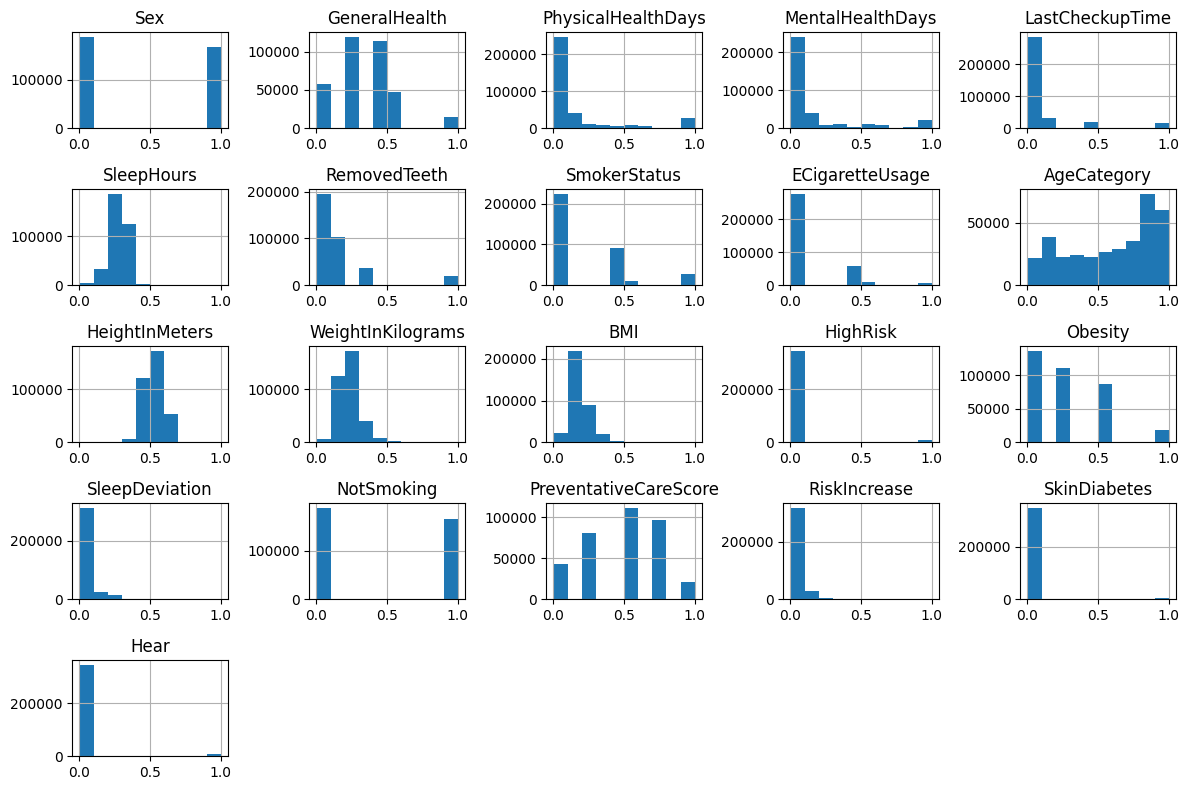

In [41]:
df_trn2[num_cols].hist(figsize=(12,8))
plt.tight_layout()

In [42]:
# 'df_trn' 데이터프레임에서 'cat_cols'에 포함된 카테고리형 컬럼들을 대상으로, 
# 'Yes', 'No', NaN 만 포함된 컬럼(yn_cols)과, 그 외의 다른 값이 포함된 컬럼(not_yn_cols)을 분리하여 찾음
yn_cols = [col for col in df_trn[cat_cols].columns if set(df_trn[col].unique()) <= {'Yes', 'No', np.nan}]
not_yn_cols = [col for col in cat_cols if not set(df_trn[col].unique()) <= {'Yes', 'No', np.nan}]

* yes,no로 구분된 변수 시각화

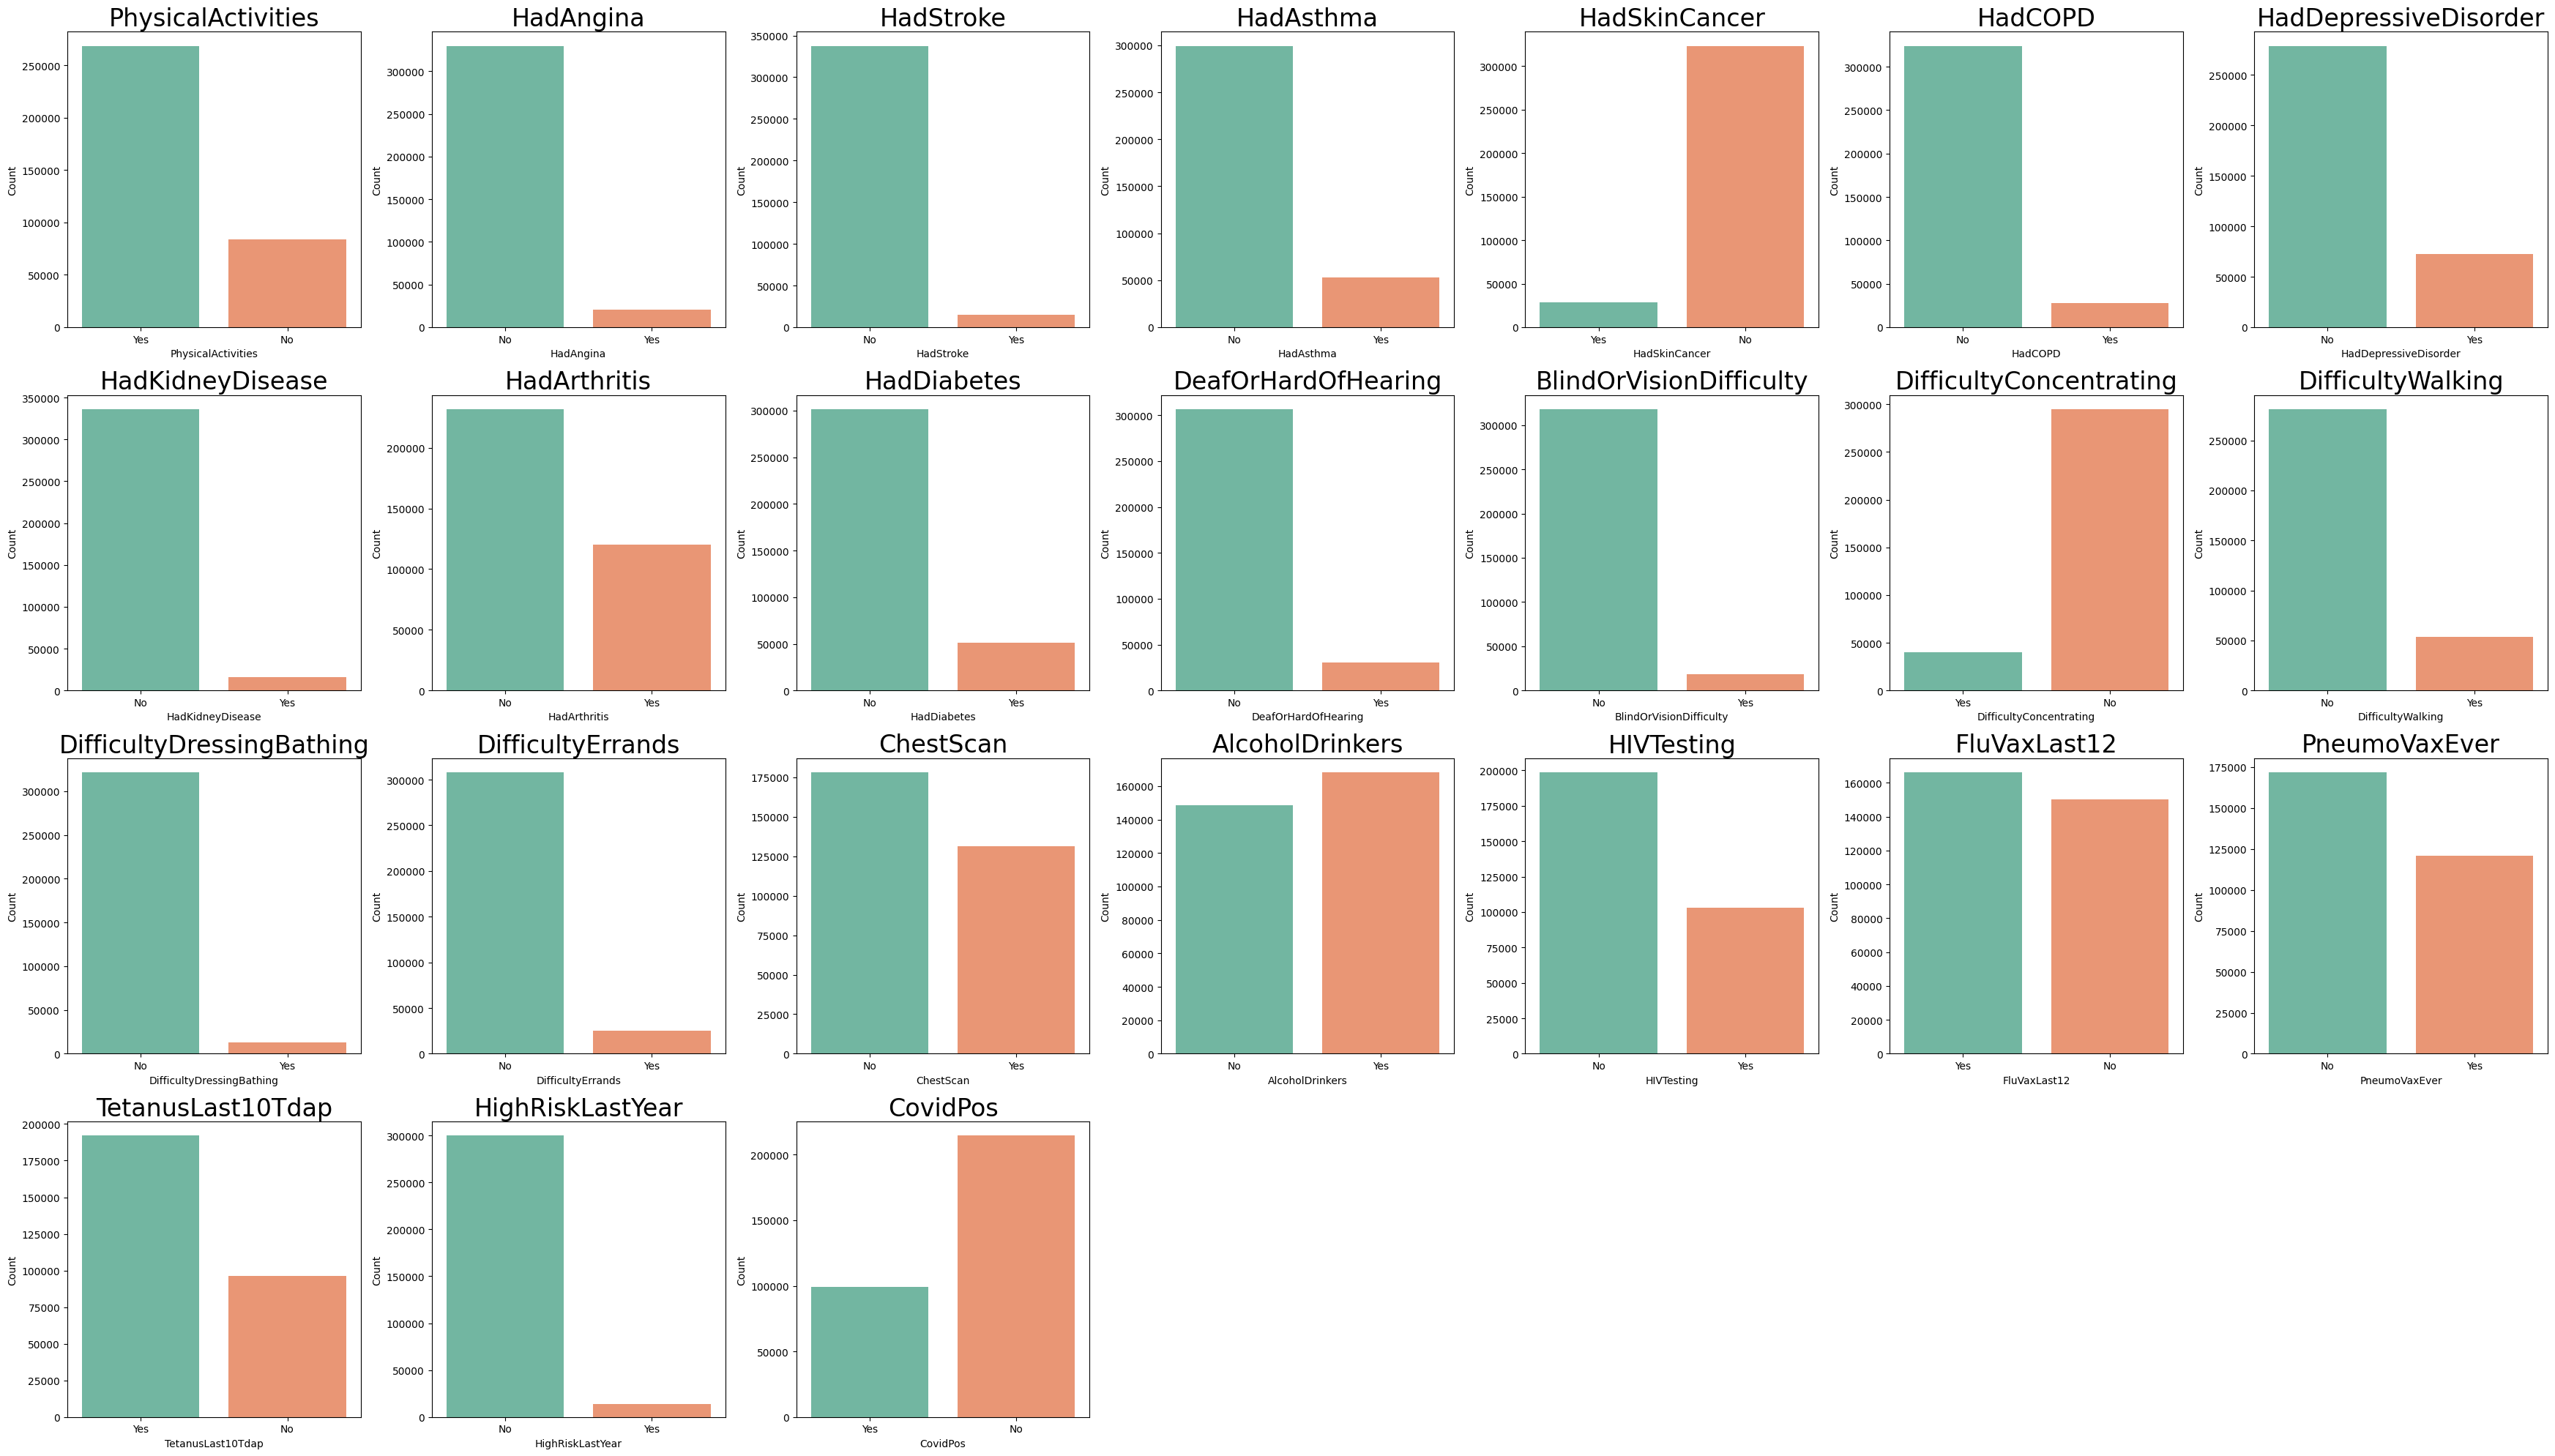

In [43]:
# 변수 개수와 행, 열의 수를 설정
n_cols = 7  # 한 행에 표시할 변수 개수 (여기서는 3개)
n_rows = (len(yn_cols) + n_cols - 1) // n_cols  # 필요한 행의 수 계산

# 전체 그림 크기 설정 (각 서브플롯의 크기를 고려해서 조정)
plt.figure(figsize=(n_cols * 5, n_rows * 5))

# 각 범주형 변수에 대해 countplot을 그립니다
for i, col in enumerate(yn_cols, 1):
    plt.subplot(n_rows, n_cols, i)  # 서브플롯 지정 (n_rows x n_cols)
    sns.countplot(x=col, data=df_trn, palette="Set2")
    plt.title(f'{col}', fontsize=24)
    plt.xlabel(col)
    plt.ylabel('Count')

# 레이아웃 조정
plt.tight_layout()
plt.show()

## 최종 상관계수 확인

In [44]:
df_trn_preprocessed = pd.concat((df_trn2, df_trn['HadHeartAttack']), axis=1)

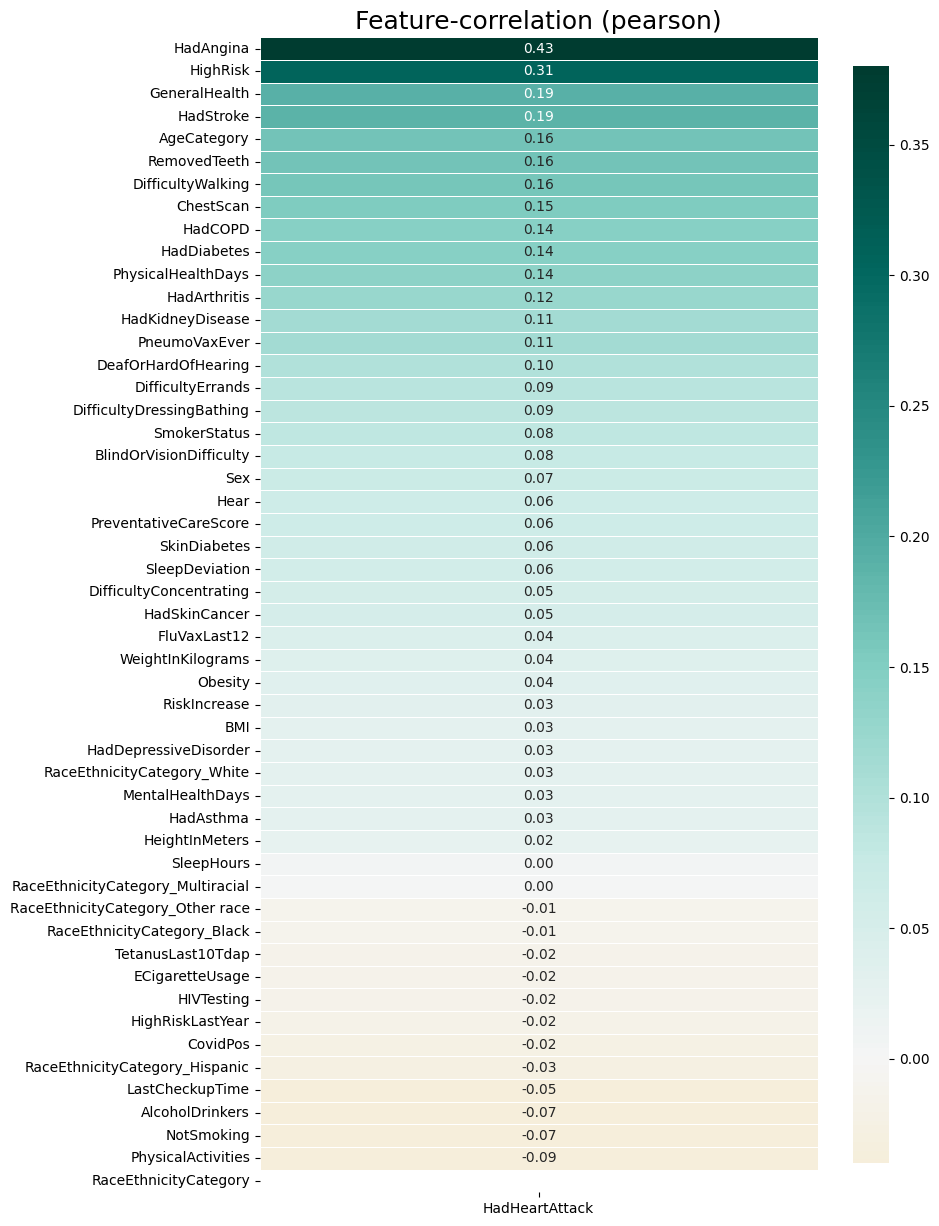

In [45]:
import klib

klib.corr_plot(data = df_trn_preprocessed.drop(columns=['HadHeartAttack']),
               target = df_trn['HadHeartAttack'],
               figsize = (9, 15))

plt.show()

## Feature Selection

In [46]:
X_train = df_trn_preprocessed.drop(columns=['HadHeartAttack'])
y_train = df_trn['HadHeartAttack']

X_test = df_tst2

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 20086, number of negative: 333567
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038925 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 877
[LightGBM] [Info] Number of data points in the train set: 353653, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.056796 -> initscore=-2.809821
[LightGBM] [Info] Start training from score -2.809821


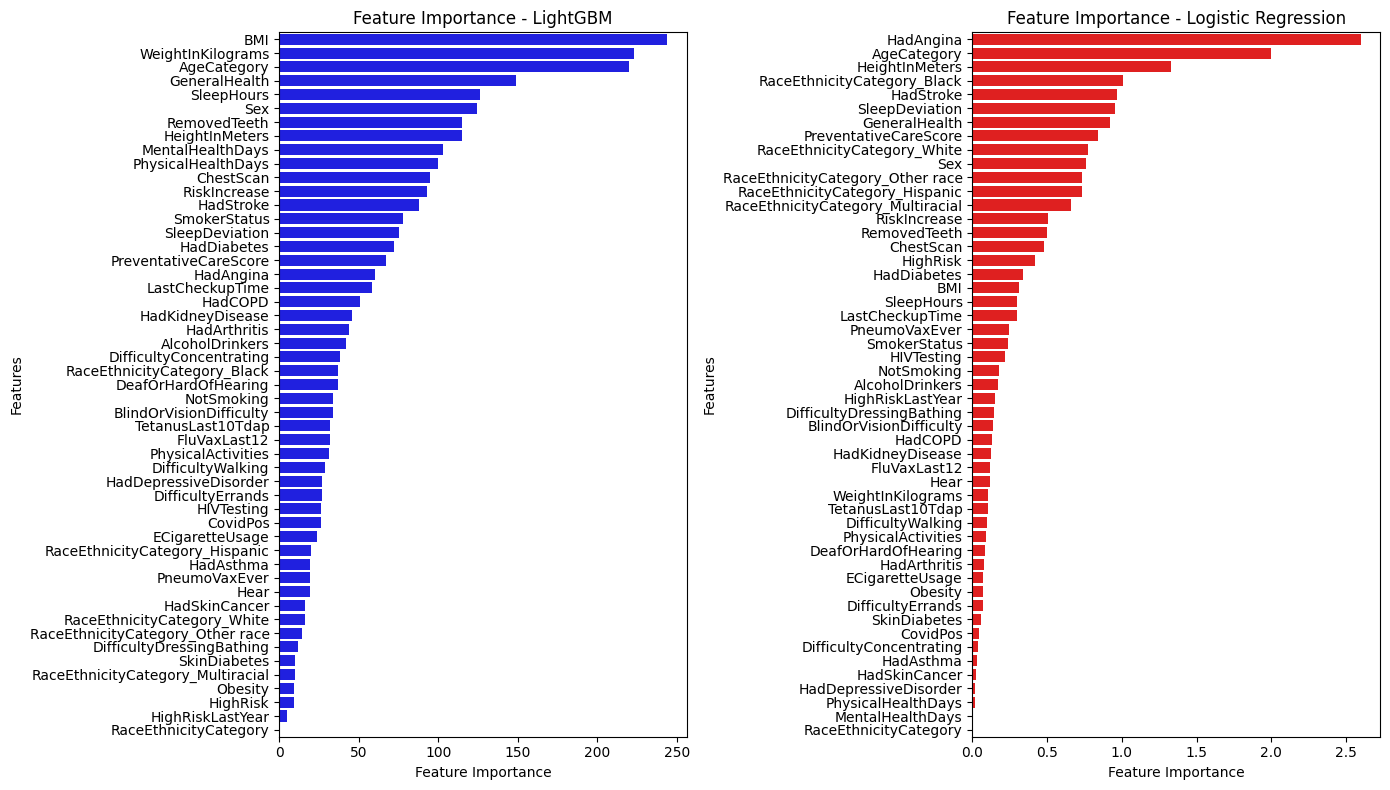

In [47]:
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# LightGBM 모델 학습 (예시)
lgbm_model = lgb.LGBMClassifier()
lgbm_model.fit(X_train, y_train)  # X_train, y_train은 훈련 데이터

# 로지스틱 회귀 모델 학습 (예시)
logreg_model = LogisticRegression()
logreg_model.fit(X_train, y_train)  # X_train, y_train은 훈련 데이터

# 1. LightGBM 피처 중요도 추출
lgbm_feature_importance = lgbm_model.feature_importances_

# 2. 로지스틱 회귀 피처 임포턴스 (회귀 계수) 추출
logreg_feature_importance = abs(logreg_model.coef_[0])

# 3. 피처 중요도와 피처 이름을 데이터프레임으로 만들어서 정렬

# LightGBM 데이터프레임
lgbm_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_LGBM': lgbm_feature_importance
})
lgbm_importance_df = lgbm_importance_df.sort_values(by='Importance_LGBM', ascending=False)

# 로지스틱 회귀 데이터프레임
logreg_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_LogReg': logreg_feature_importance
})
logreg_importance_df = logreg_importance_df.sort_values(by='Importance_LogReg', ascending=False)

# 시각화 (두 모델을 분할하여)
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# 1. LightGBM 피처 중요도 시각화
sns.barplot(x='Importance_LGBM', y='Feature', data=lgbm_importance_df, ax=axes[0], color='blue')
axes[0].set_title("Feature Importance - LightGBM")
axes[0].set_xlabel("Feature Importance")
axes[0].set_ylabel("Features")

# 2. 로지스틱 회귀 피처 중요도 시각화
sns.barplot(x='Importance_LogReg', y='Feature', data=logreg_importance_df, ax=axes[1], color='red')
axes[1].set_title("Feature Importance - Logistic Regression")
axes[1].set_xlabel("Feature Importance")
axes[1].set_ylabel("Features")

# 레이아웃 조정 및 표시
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation > 0.8')

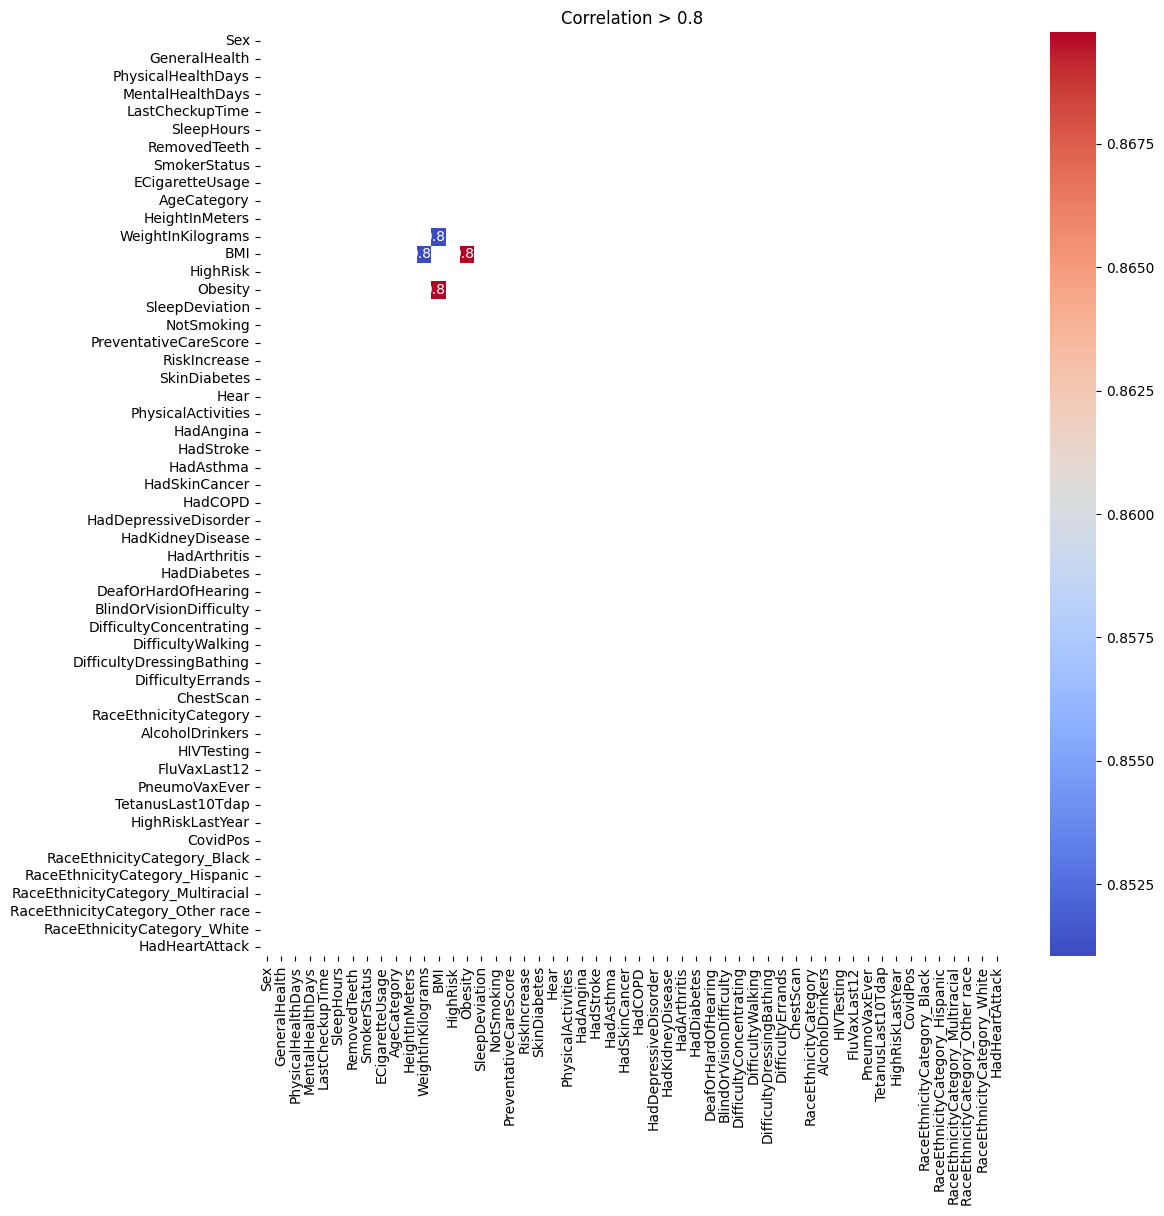

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 상관관계 계산
correlation_matrix = df_trn_preprocessed.corr()

# 상관계수 0.9 이상인 부분만 추출 (자기 자신 제외)
high_corr = correlation_matrix[(correlation_matrix > 0.8) & (correlation_matrix != 1.0)]

# 시각화
plt.figure(figsize=(12, 12))
sns.heatmap(high_corr, annot=True, cmap='coolwarm', mask=(correlation_matrix < 0.8), fmt=".2f")
plt.title("Correlation > 0.8")

## 성능 확인(파라미터 고정)

In [49]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

X = df_trn_preprocessed.drop(['HadHeartAttack'], axis=1) 
y = df_trn_preprocessed['HadHeartAttack']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 1. SMOTE 적용 (훈련 데이터 오버샘플링)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 2. 개별 모델 생성 (LogisticRegression과 LGBM)
lr_model = LogisticRegression(random_state=42, penalty='l2', C=1, solver='liblinear', class_weight='balanced')  # 설정된 파라미터
lgb_model = lgb.LGBMClassifier(random_state=42, num_leaves=50, max_depth=5, class_weight='balanced', verbose=-1)  # 설정된 파라미터

# 3. 보팅 모델 생성 (Soft Voting)
voting_model = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('lgb', lgb_model)
    ],
    voting='soft'  # 'soft'를 사용하여 확률 기반 보팅도 가능
)

# 4. 모델 학습
voting_model.fit(X_train_resampled, y_train_resampled)

# 5. 테스트 데이터에 대한 예측 확률
y_pred_prob = voting_model.predict_proba(X_test)[:, 1]  # 긍정 클래스에 대한 예측 확률 (1번 클래스)
# 6. ROC AUC 계산
roc_auc = roc_auc_score(y_test, y_pred_prob)
# 7. 결과 출력
print("ROC AUC Score: ", roc_auc)

ROC AUC Score:  0.8667902273500407


-피처 제거 후 성능 확인

In [50]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

X = df_trn_preprocessed.drop(['HadHeartAttack','WeightInKilograms','Obesity'], axis=1) 
y = df_trn_preprocessed['HadHeartAttack']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 1. SMOTE 적용 (훈련 데이터 오버샘플링)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 2. 개별 모델 생성 (LogisticRegression과 LGBM)
lr_model = LogisticRegression(random_state=42, penalty='l2', C=1, solver='liblinear', class_weight='balanced')  # 설정된 파라미터
lgb_model = lgb.LGBMClassifier(random_state=42, num_leaves=50, max_depth=5, class_weight='balanced', verbose=-1)  # 설정된 파라미터

# 3. 보팅 모델 생성 (Soft Voting)
voting_model = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('lgb', lgb_model)
    ],
    voting='soft'  # 'soft'를 사용하여 확률 기반 보팅도 가능
)

# 4. 모델 학습
voting_model.fit(X_train_resampled, y_train_resampled)

# 5. 테스트 데이터에 대한 예측 확률
y_pred_prob = voting_model.predict_proba(X_test)[:, 1]  # 긍정 클래스에 대한 예측 확률 (1번 클래스)
# 6. ROC AUC 계산
roc_auc = roc_auc_score(y_test, y_pred_prob)
# 7. 결과 출력
print("ROC AUC Score: ", roc_auc)

ROC AUC Score:  0.8669411246462659


## 모델 예측

In [51]:
X_train = df_trn_preprocessed.drop(columns=['HadHeartAttack','WeightInKilograms','Obesity'])
y_train = df_trn['HadHeartAttack']

X_test = df_tst2.drop(columns=['WeightInKilograms','Obesity'])

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression  # Logistic Regression 모델 추가
import lightgbm as lgb

# 1. SMOTE 적용 (훈련 데이터 오버샘플링)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 2. 개별 모델 생성 (LogisticRegression과 LGBM)
lr_model = LogisticRegression(random_state=42)  # LogisticRegression
lgb_model = lgb.LGBMClassifier(random_state=42)  # LightGBM

# 3. 보팅 모델 생성 (Soft Voting)
voting_model = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('lgb', lgb_model)
    ],
    voting='soft'  # 'soft'를 사용하여 확률 기반 보팅도 가능
)

# 4. GridSearchCV 설정 (하이퍼파라미터 그리드에 class_weight를 추가)
param_grid = {
    # Logistic Regression 하이퍼파라미터 튜닝
    'lr__penalty': ['l2', 'none'],  # 로지스틱 회귀의 regularization
    'lr__C': [0.01, 0.1, 1, 10],  # Regularization strength
    'lr__solver': ['liblinear', 'lbfgs'],  # 솔버
    'lr__class_weight': ['balanced', None],  # 클래스 가중치 설정

    # LightGBM 하이퍼파라미터 튜닝
    'lgb__num_leaves': [31, 50, 100],  # LightGBM의 num_leaves 하이퍼파라미터
    'lgb__max_depth': [-1, 5, 10],  # LightGBM의 max_depth
    'lgb__class_weight': ['balanced', None, {0: 1, 1: 2}, {0: 1, 1: 3}],  # LightGBM의 class_weight 추가
}

# 5. GridSearchCV 수행
gcv = GridSearchCV(voting_model,                # 모델
                   param_grid=param_grid,       # 하이퍼파라미터
                   cv=3,                        # 교차 검증
                   scoring='roc_auc',           # 평가 지표
                   n_jobs=-1)                   # 모든 코어 사용

# 6. 모델 학습
gcv.fit(X_train_resampled, y_train_resampled)

# 7. 최적 파라미터 출력
print('Final Params:', gcv.best_params_)

# 8. 최고의 성능 출력
print('Best Score:', gcv.best_score_)

# 9. 테스트 데이터에 대한 예측
y_pred = gcv.predict(X_test)

## 실제로는 실행시켰습니다 ##

## 제출

In [52]:
df_submission = pd.read_csv('submission.csv')

In [53]:
df_submission.head()

,ID,HadHeartAttack
0,425295,0
1,169359,0
2,69449,0
3,10517,0
4,62046,0


In [ ]:
df_submission['HadHeartAttack'] = y_pred

In [54]:
df_submission['HadHeartAttack'].value_counts()

HadHeartAttack
0    88414
Name: count, dtype: int64

In [55]:
# 새로운 파일로 저장하기
filename = '화학자들_최종.csv'
df_submission.to_csv(filename, index=False)

## 참고

* OverSampling 전후비교

Before SMOTE: Counter({0: 333567, 1: 20086})
After SMOTE: Counter({0: 333567, 1: 333567})


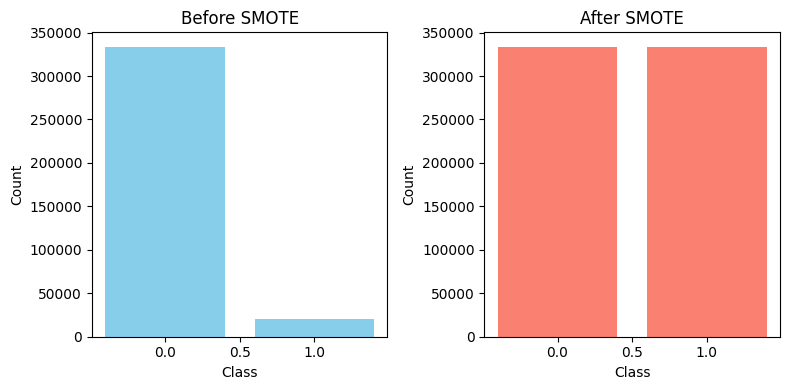

In [56]:
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.over_sampling import SMOTE

# SMOTE 적용 전
original_counter = Counter(y_train)
print(f"Before SMOTE: {original_counter}")

# 1. SMOTE 적용 (훈련 데이터 오버샘플링)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# SMOTE 적용 후
resampled_counter = Counter(y_train_resampled)
print(f"After SMOTE: {resampled_counter}")

# 2. 시각화 (Before and After SMOTE)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# SMOTE 전 클래스 분포
axes[0].bar(original_counter.keys(), original_counter.values(), color='skyblue')
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

# SMOTE 후 클래스 분포
axes[1].bar(resampled_counter.keys(), resampled_counter.values(), color='salmon')
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# ***수고하셨습니다!!***